Dataset size: 9588
Epoch 1 | D Loss: 0.7638 | G Loss: 2.3427
Epoch 2 | D Loss: 0.5762 | G Loss: 4.4023
Epoch 3 | D Loss: 0.4626 | G Loss: 5.5916
Epoch 4 | D Loss: 0.4658 | G Loss: 4.3862
Epoch 5 | D Loss: 0.3864 | G Loss: 5.2963
Epoch 6 | D Loss: 1.0876 | G Loss: 8.1239
Epoch 7 | D Loss: 0.3563 | G Loss: 3.7645
Epoch 8 | D Loss: 0.7259 | G Loss: 3.0586
Epoch 9 | D Loss: 0.4845 | G Loss: 3.0818
Epoch 10 | D Loss: 0.2112 | G Loss: 5.8715


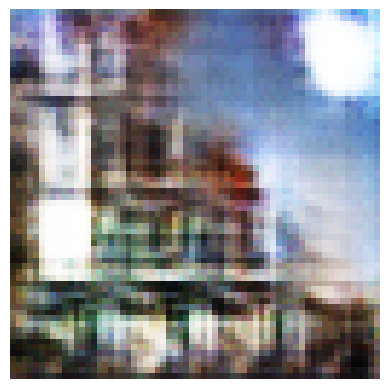

Dataset size: 9588
Epoch 1 | D Loss: 0.9594 | G Loss: 5.1608
Epoch 2 | D Loss: 0.3458 | G Loss: 3.5576
Epoch 3 | D Loss: 0.4958 | G Loss: 4.5592
Epoch 4 | D Loss: 0.6874 | G Loss: 4.2024
Epoch 5 | D Loss: 0.4863 | G Loss: 4.0708
Epoch 6 | D Loss: 0.5353 | G Loss: 4.8827
Epoch 7 | D Loss: 0.7335 | G Loss: 7.6582
Epoch 8 | D Loss: 0.8317 | G Loss: 4.9481


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import open_clip
import numpy as np
from PIL import Image
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# DEVICE
device = "cuda" if torch.cuda.is_available() else "cpu"


# LOAD CLIP
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model = model.to(device)
tokenizer = open_clip.get_tokenizer('ViT-B-32')


# DATASET
DATASET_PATH = "/content/drive/MyDrive/arcDataset"

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Dataset size:", len(dataset))


# GENERATOR (64x64)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# DISCRIMINATOR
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 8, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)


# INIT MODELS
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))


# CLIP LOSS
def get_text_embedding(text):
    tokens = tokenizer([text]).to(device)
    with torch.no_grad():
        emb = model.encode_text(tokens)
    return F.normalize(emb, dim=-1)


def clip_loss(fake_images, prompt):
    text_emb = get_text_embedding(prompt)

    imgs = F.interpolate(fake_images, size=224)

    with torch.no_grad():
        image_emb = model.encode_image(imgs)
        image_emb = F.normalize(image_emb, dim=-1)

    similarity = (image_emb @ text_emb.T).mean()
    return 1 - similarity


# TRAINING
EPOCHS = 10

for epoch in range(EPOCHS):
    for real, _ in dataloader:

        real = real.to(device)
        batch = real.size(0)

        real_labels = torch.ones(batch, 1).to(device)
        fake_labels = torch.zeros(batch, 1).to(device)

        # TRAIN DISCRIMINATOR
        noise = torch.randn(batch, 100, 1, 1).to(device)
        fake = G(noise)

        loss_D_real = criterion(D(real), real_labels)
        loss_D_fake = criterion(D(fake.detach()), fake_labels)
        loss_D = loss_D_real + loss_D_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # TRAIN GENERATOR
        output = D(fake)
        loss_G = criterion(output, real_labels)

        prompt = "modern architectural building"
        loss_G += 0.3 * clip_loss(fake, prompt)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")


# GENERATE IMAGE
def generate_image():
    noise = torch.randn(1, 100, 1, 1).to(device)
    fake = G(noise).detach().cpu()

    img = (fake.squeeze().permute(1, 2, 0) + 1) / 2
    plt.imshow(img)
    plt.axis('off')
    plt.show()


# Generate sample
generate_image()